In [53]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [54]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [55]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


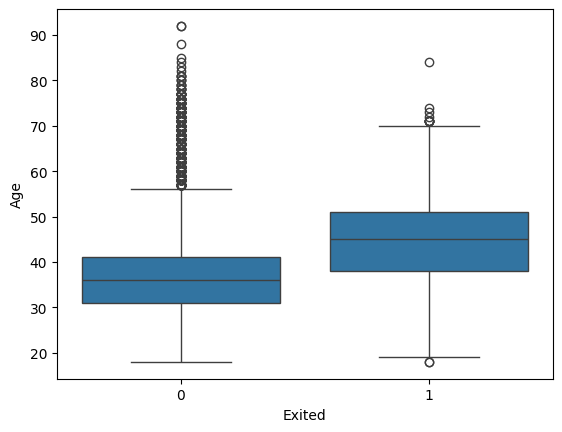

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

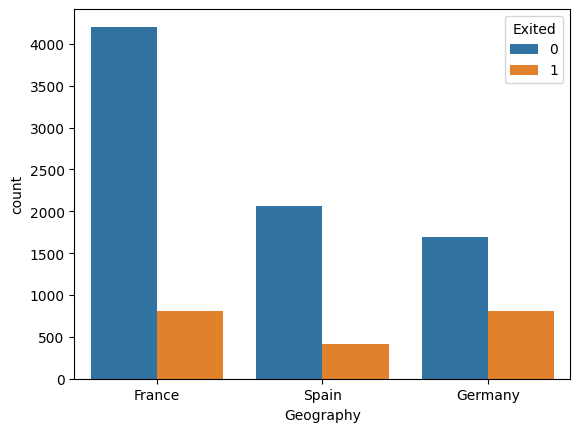

In [57]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

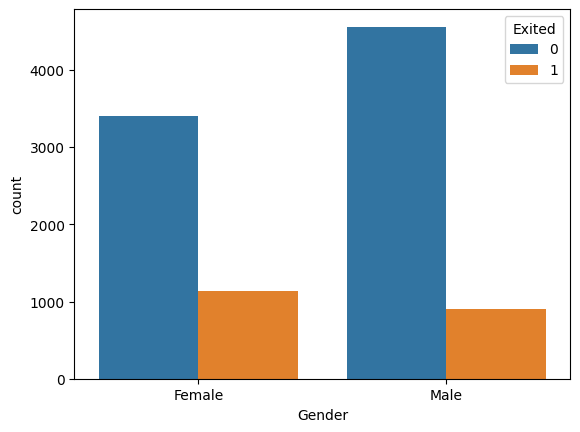

In [58]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

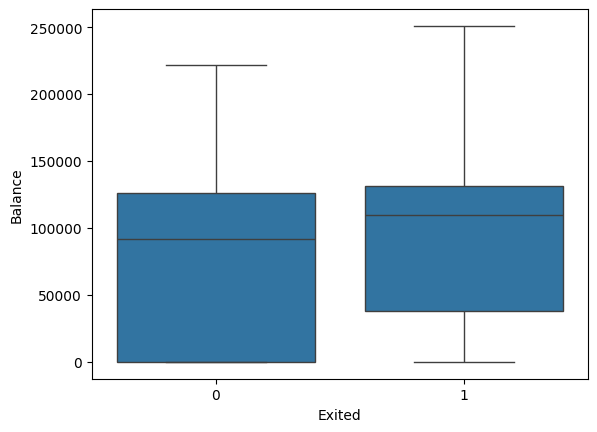

In [59]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

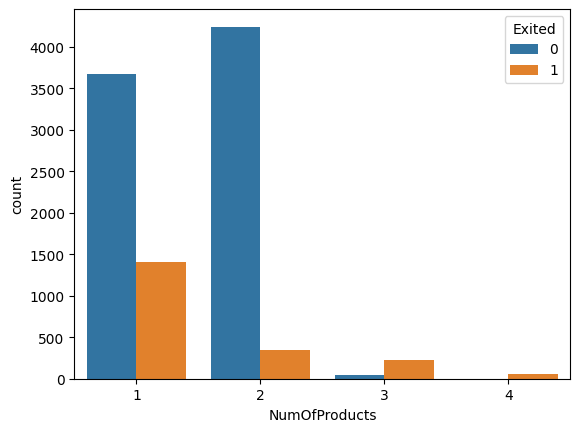

In [60]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.show()

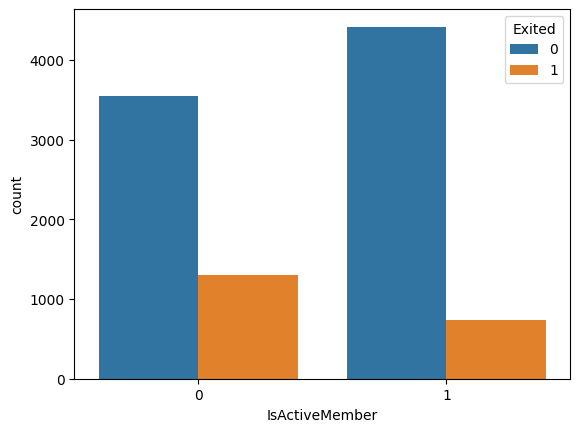

In [61]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.show()

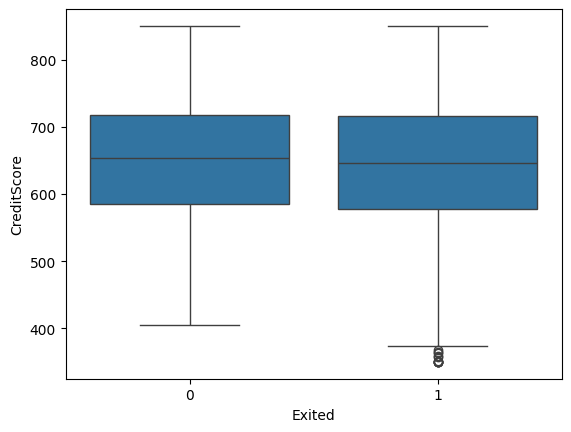

In [62]:
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.show()

In [63]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [64]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df['Geography'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 301.25533682434536
p-value: 3.8303176053541544e-66


In [65]:
cont_table = pd.crosstab(df['Gender'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(cont_table)

print("p-value:", p)

p-value: 2.2482100097131755e-26


In [66]:
from scipy.stats import f_oneway

group0 = df[df['Exited']==0]['Age']
group1 = df[df['Exited']==1]['Age']

f_stat, p = f_oneway(group0, group1)

print("p-value:", p)

p-value: 1.2399313093459443e-186


In [67]:
group0 = df[df['Exited']==0]['Balance']
group1 = df[df['Exited']==1]['Balance']

f_stat, p = f_oneway(group0, group1)

print("p-value:", p)

p-value: 1.2755633191546494e-32


In [68]:
import pandas as pd
from scipy.stats import pointbiserialr

# تحديد الأعمدة الرقمية
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# نشيل التارجت من الليست
numeric_cols = numeric_cols.drop('Exited')

results = []

for col in numeric_cols:
    corr, p = pointbiserialr(df['Exited'], df[col])
    results.append([col, corr, p])

# نحطهم في DataFrame
pb_results = pd.DataFrame(results, columns=['Feature', 'Correlation', 'P-value'])

# نرتب حسب قوة العلاقة
pb_results = pb_results.sort_values(by='Correlation', key=abs, ascending=False)

print(pb_results)

           Feature  Correlation        P-value
1              Age     0.285323  1.239931e-186
6   IsActiveMember    -0.156128   1.348269e-55
3          Balance     0.118533   1.275563e-32
4    NumOfProducts    -0.047820   1.717333e-06
0      CreditScore    -0.027094   6.738214e-03
2           Tenure    -0.014001   1.615268e-01
7  EstimatedSalary     0.012097   2.264404e-01
5        HasCrCard    -0.007138   4.754149e-01


In [69]:
df_original = df.copy()

In [70]:
df_encoded = pd.get_dummies(df_original, drop_first=True)

In [71]:
X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.9079754601226995


In [48]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


In [49]:
best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8641276098903219

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1593
           1       0.53      0.74      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.83      2000



In [74]:
import pandas as pd

importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance
4       NumOfProducts    0.312722
1                 Age    0.169748
6      IsActiveMember    0.149839
8   Geography_Germany    0.099509
3             Balance    0.064366
10        Gender_Male    0.052212
9     Geography_Spain    0.036841
0         CreditScore    0.031432
7     EstimatedSalary    0.031025
2              Tenure    0.027839
5           HasCrCard    0.024465


Train F1: 0.697841726618705
Test F1: 0.6209016393442623


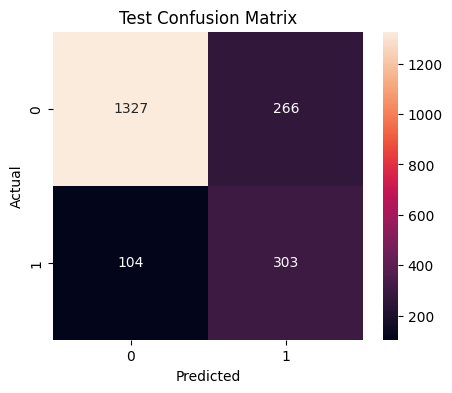

In [51]:
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Train Predictions =====
y_pred_train = best_model.predict(X_train)

# ===== F1 Scores =====
print("Train F1:", f1_score(y_train, y_pred_train))
print("Test F1:", f1_score(y_test, y_pred))


# ===== Confusion Matrix - Test =====
cm_test = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Random Forest**


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'  # مهم لو الداتا imbalanced
)

In [76]:
param_dist_rf = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [77]:
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best RF Params:", random_search_rf.best_params_)

Best RF Params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}


In [78]:
best_rf = random_search_rf.best_estimator_

# Predictions
y_pred_rf_train = best_rf.predict(X_train)
y_pred_rf_test = best_rf.predict(X_test)

from sklearn.metrics import f1_score, classification_report

print("RF Train F1:", f1_score(y_train, y_pred_rf_train))
print("RF Test F1:", f1_score(y_test, y_pred_rf_test))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_pred_rf_test))

RF Train F1: 0.8437317784256559
RF Test F1: 0.6294919454770755

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.64      0.62      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



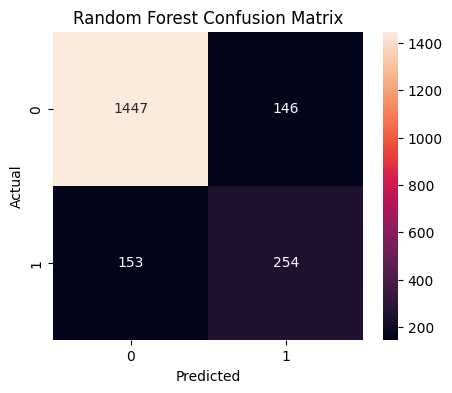

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()